In [71]:
import sympy as sp

In [72]:
phi1_star, phi2_star = sp.symbols('phi_1^* phi_2^*', real=True)
kappa = sp.symbols('kappa', real=True, positive=True)
beta = sp.symbols(r'\beta', real=True, positive=True)


# 为简化书写，定义中间变量
# a1, a2 = sp.symbols("a_1 a_2", real=True)
a1 = sp.cos(phi1_star) + kappa  # 对应 cos(φ₁*) + κ₁
a2 = sp.cos(phi2_star) + kappa  # 对应 cos(φ₂*) + κ₂

# 构造 Jacobian 矩阵 J
# 状态顺序: [φ₁, v₁, φ₂, v₂]
J = sp.Matrix([
    [0,          0,       1,          0],
    [0,          0,       0,          1],
    [-a1,   kappa,      -beta,      0],
    [kappa,      -a2,     0,      -beta]
])

J

Matrix([
[                    0,                     0,      1,      0],
[                    0,                     0,      0,      1],
[-kappa - cos(phi_1^*),                 kappa, -\beta,      0],
[                kappa, -kappa - cos(phi_2^*),      0, -\beta]])

In [73]:
# 计算特征多项式 det(J - λI)
lam = sp.symbols('lambda')
char_poly = J.charpoly(lam)

sp.sympify(char_poly.as_expr())

2*\beta*lambda**3 + kappa*cos(phi_1^*) + kappa*cos(phi_2^*) + lambda**4 + lambda**2*(\beta**2 + 2*kappa + cos(phi_1^*) + cos(phi_2^*)) + lambda*(2*\beta*kappa + \beta*cos(phi_1^*) + \beta*cos(phi_2^*)) + cos(phi_1^*)*cos(phi_2^*)

In [74]:
eigenvalues = J.eigenvals()
print(f"\n特征值 (解析形式):")


特征值 (解析形式):


In [75]:
print(f"\n特征值 (解析形式):")
for ev, mult in eigenvalues.items():
    print(f"  λ = {ev}\n (重数: {mult})\n")


特征值 (解析形式):
  λ = -\beta/2 - sqrt(\beta**2 - 4*kappa - 2*sqrt(4*kappa**2 + cos(phi_1^*)**2 - 2*cos(phi_1^*)*cos(phi_2^*) + cos(phi_2^*)**2) - 2*cos(phi_1^*) - 2*cos(phi_2^*))/2
 (重数: 1)

  λ = -\beta/2 + sqrt(\beta**2 - 4*kappa - 2*sqrt(4*kappa**2 + cos(phi_1^*)**2 - 2*cos(phi_1^*)*cos(phi_2^*) + cos(phi_2^*)**2) - 2*cos(phi_1^*) - 2*cos(phi_2^*))/2
 (重数: 1)

  λ = -\beta/2 - sqrt(\beta**2 - 4*kappa + 2*sqrt(4*kappa**2 + cos(phi_1^*)**2 - 2*cos(phi_1^*)*cos(phi_2^*) + cos(phi_2^*)**2) - 2*cos(phi_1^*) - 2*cos(phi_2^*))/2
 (重数: 1)

  λ = -\beta/2 + sqrt(\beta**2 - 4*kappa + 2*sqrt(4*kappa**2 + cos(phi_1^*)**2 - 2*cos(phi_1^*)*cos(phi_2^*) + cos(phi_2^*)**2) - 2*cos(phi_1^*) - 2*cos(phi_2^*))/2
 (重数: 1)



In [76]:
list(eigenvalues.items())[0][0]

-\beta/2 - sqrt(\beta**2 - 4*kappa - 2*sqrt(4*kappa**2 + cos(phi_1^*)**2 - 2*cos(phi_1^*)*cos(phi_2^*) + cos(phi_2^*)**2) - 2*cos(phi_1^*) - 2*cos(phi_2^*))/2

In [77]:
conditions

[-\beta/2 - ((\beta**2 - 4*kappa - 2*cos(phi_1^*) - 2*cos(phi_2^*) - 2*cos(atan2(0, 4*kappa**2 + cos(phi_1^*)**2 - 2*cos(phi_1^*)*cos(phi_2^*) + cos(phi_2^*)**2)/2)*sqrt(Abs(4*kappa**2 + cos(phi_1^*)**2 - 2*cos(phi_1^*)*cos(phi_2^*) + cos(phi_2^*)**2)))**2 + 4*sin(atan2(0, 4*kappa**2 + cos(phi_1^*)**2 - 2*cos(phi_1^*)*cos(phi_2^*) + cos(phi_2^*)**2)/2)**2*Abs(4*kappa**2 + cos(phi_1^*)**2 - 2*cos(phi_1^*)*cos(phi_2^*) + cos(phi_2^*)**2))**(1/4)*cos(atan2(-2*sin(atan2(0, 4*kappa**2 + cos(phi_1^*)**2 - 2*cos(phi_1^*)*cos(phi_2^*) + cos(phi_2^*)**2)/2)*sqrt(Abs(4*kappa**2 + cos(phi_1^*)**2 - 2*cos(phi_1^*)*cos(phi_2^*) + cos(phi_2^*)**2)), \beta**2 - 4*kappa - 2*cos(phi_1^*) - 2*cos(phi_2^*) - 2*cos(atan2(0, 4*kappa**2 + cos(phi_1^*)**2 - 2*cos(phi_1^*)*cos(phi_2^*) + cos(phi_2^*)**2)/2)*sqrt(Abs(4*kappa**2 + cos(phi_1^*)**2 - 2*cos(phi_1^*)*cos(phi_2^*) + cos(phi_2^*)**2)))/2)/2 < 0,
 -\beta/2 + ((\beta**2 - 4*kappa - 2*cos(phi_1^*) - 2*cos(phi_2^*) - 2*cos(atan2(0, 4*kappa**2 + cos(phi_1

In [78]:
import sympy as sp

# 获取特征多项式系数（降幂排列）
lam = sp.symbols('lambda')
char_poly: sp.PurePoly = J.charpoly(lam)
coeffs = char_poly.all_coeffs()  # [1, c3, c2, c1, c0]

print(coeffs)

c3, c2, c1, c0 = coeffs[1], coeffs[2], coeffs[3], coeffs[4]

print("特征多项式系数:")
print(f"c3 = {c3}")
print(f"c2 = {c2}")
print(f"c1 = {c1}")
print(f"c0 = {c0}")

# 构造 Routh-Hurwitz 条件（4阶系统）
# 条件1: 所有系数为正
cond1 = sp.And(c3 > 0, c2 > 0, c1 > 0, c0 > 0)

# 条件2: c3*c2 > c1
cond2 = c3*c2 - c1 > 0

# 条件3: (c3*c2 - c1)*c1 > c3^2*c0
cond3 = (c3*c2 - c1)*c1 - c3**2*c0 > 0

# 综合稳定条件
stability_conditions = sp.And(cond1, cond2, cond3)

print("\n稳定性条件:")
print(f"条件1 (系数全正): {cond1}")
print(f"条件2: {cond2}")
print(f"条件3: {cond3}")

[1, 2*\beta, \beta**2 + 2*kappa + cos(phi_1^*) + cos(phi_2^*), 2*\beta*kappa + \beta*cos(phi_1^*) + \beta*cos(phi_2^*), kappa*cos(phi_1^*) + kappa*cos(phi_2^*) + cos(phi_1^*)*cos(phi_2^*)]
特征多项式系数:
c3 = 2*\beta
c2 = \beta**2 + 2*kappa + cos(phi_1^*) + cos(phi_2^*)
c1 = 2*\beta*kappa + \beta*cos(phi_1^*) + \beta*cos(phi_2^*)
c0 = kappa*cos(phi_1^*) + kappa*cos(phi_2^*) + cos(phi_1^*)*cos(phi_2^*)

稳定性条件:
条件1 (系数全正): (\beta**2 + 2*kappa + cos(phi_1^*) + cos(phi_2^*) > 0) & (2*\beta*kappa + \beta*cos(phi_1^*) + \beta*cos(phi_2^*) > 0) & (kappa*cos(phi_1^*) + kappa*cos(phi_2^*) + cos(phi_1^*)*cos(phi_2^*) > 0)
条件2: -2*\beta*kappa + 2*\beta*(\beta**2 + 2*kappa + cos(phi_1^*) + cos(phi_2^*)) - \beta*cos(phi_1^*) - \beta*cos(phi_2^*) > 0
条件3: -4*\beta**2*(kappa*cos(phi_1^*) + kappa*cos(phi_2^*) + cos(phi_1^*)*cos(phi_2^*)) + (2*\beta*kappa + \beta*cos(phi_1^*) + \beta*cos(phi_2^*))*(-2*\beta*kappa + 2*\beta*(\beta**2 + 2*kappa + cos(phi_1^*) + cos(phi_2^*)) - \beta*cos(phi_1^*) - \beta*cos(ph

In [79]:
cond1

(\beta**2 + 2*kappa + cos(phi_1^*) + cos(phi_2^*) > 0) & (2*\beta*kappa + \beta*cos(phi_1^*) + \beta*cos(phi_2^*) > 0) & (kappa*cos(phi_1^*) + kappa*cos(phi_2^*) + cos(phi_1^*)*cos(phi_2^*) > 0)

In [80]:
cond2

-2*\beta*kappa + 2*\beta*(\beta**2 + 2*kappa + cos(phi_1^*) + cos(phi_2^*)) - \beta*cos(phi_1^*) - \beta*cos(phi_2^*) > 0

In [81]:
cond3

-4*\beta**2*(kappa*cos(phi_1^*) + kappa*cos(phi_2^*) + cos(phi_1^*)*cos(phi_2^*)) + (2*\beta*kappa + \beta*cos(phi_1^*) + \beta*cos(phi_2^*))*(-2*\beta*kappa + 2*\beta*(\beta**2 + 2*kappa + cos(phi_1^*) + cos(phi_2^*)) - \beta*cos(phi_1^*) - \beta*cos(phi_2^*)) > 0

In [120]:

import torch
import torchsde
import matplotlib.pyplot as plt
import numpy as np

# 设置随机种子
torch.manual_seed(42)
np.random.seed(42)

# 定义耦合SDE系统
class CoupledPhaseSDE(torchsde.SDEIto):
    def __init__(self, params):
        super().__init__(noise_type="diagonal")
        self.i1 = params['i1']
        self.i2 = params['i2']
        self.beta_J1 = params['beta_J1']
        self.beta_J2 = params['beta_J2']
        self.k1 = params['k1']
        self.k2 = params['k2']
        self.sigma1 = params['sigma1']
        self.sigma2 = params['sigma2']
        
    def f(self, t, y):
        phi1, v1, phi2, v2 = y[..., 0], y[..., 1], y[..., 2], y[..., 3]
        
        dphi1 = v1
        dv1 = (self.i1 - self.beta_J1 * v1 - torch.sin(phi1) + 
               self.k1 * (phi2 - phi1))
        dphi2 = v2
        dv2 = (self.i2 - self.beta_J2 * v2 - torch.sin(phi2) + 
               self.k2 * (phi1 - phi2))
        
        return torch.stack([dphi1, dv1, dphi2, dv2], dim=-1)
    
    def g(self, t, y):
        diffusion = torch.zeros_like(y)
        diffusion[..., 1] = self.sigma1
        diffusion[..., 3] = self.sigma2
        return diffusion

# 系统参数
params = {
    'i1': 0.8,
    'i2': 0.8,
    'beta_J1': 0.1,
    'beta_J2': 0.1,
    'k1': 0.05,
    'k2': 0.05,
    'sigma1': 0.05,
    'sigma2': 0.05
}

# 初始化与求解
sde = CoupledPhaseSDE(params)
y0 = torch.tensor([[0.0, 0.0, np.pi/2, 0.0]])
t_span = (0.0, 100.0)
t_eval = torch.linspace(t_span[0], t_span[1], 10000)

print("正在求解SDE...")
with torch.no_grad():
    ys = torchsde.sdeint(sde, y0, t_eval, method='euler', dt=0.005)

# 提取数据
t = t_eval.numpy()
phi1 = ys[:, 0, 0].numpy()
v1 = ys[:, 0, 1].numpy()
phi2 = ys[:, 0, 2].numpy()
v2 = ys[:, 0, 3].numpy()

# 计算相位差（归一化到[-pi, pi]）
phase_diff = np.mod((phi2 - phi1) + np.pi, 2*np.pi) - np.pi

print(f"模拟完成！数据点数: {len(t)}")


正在求解SDE...
模拟完成！数据点数: 10000


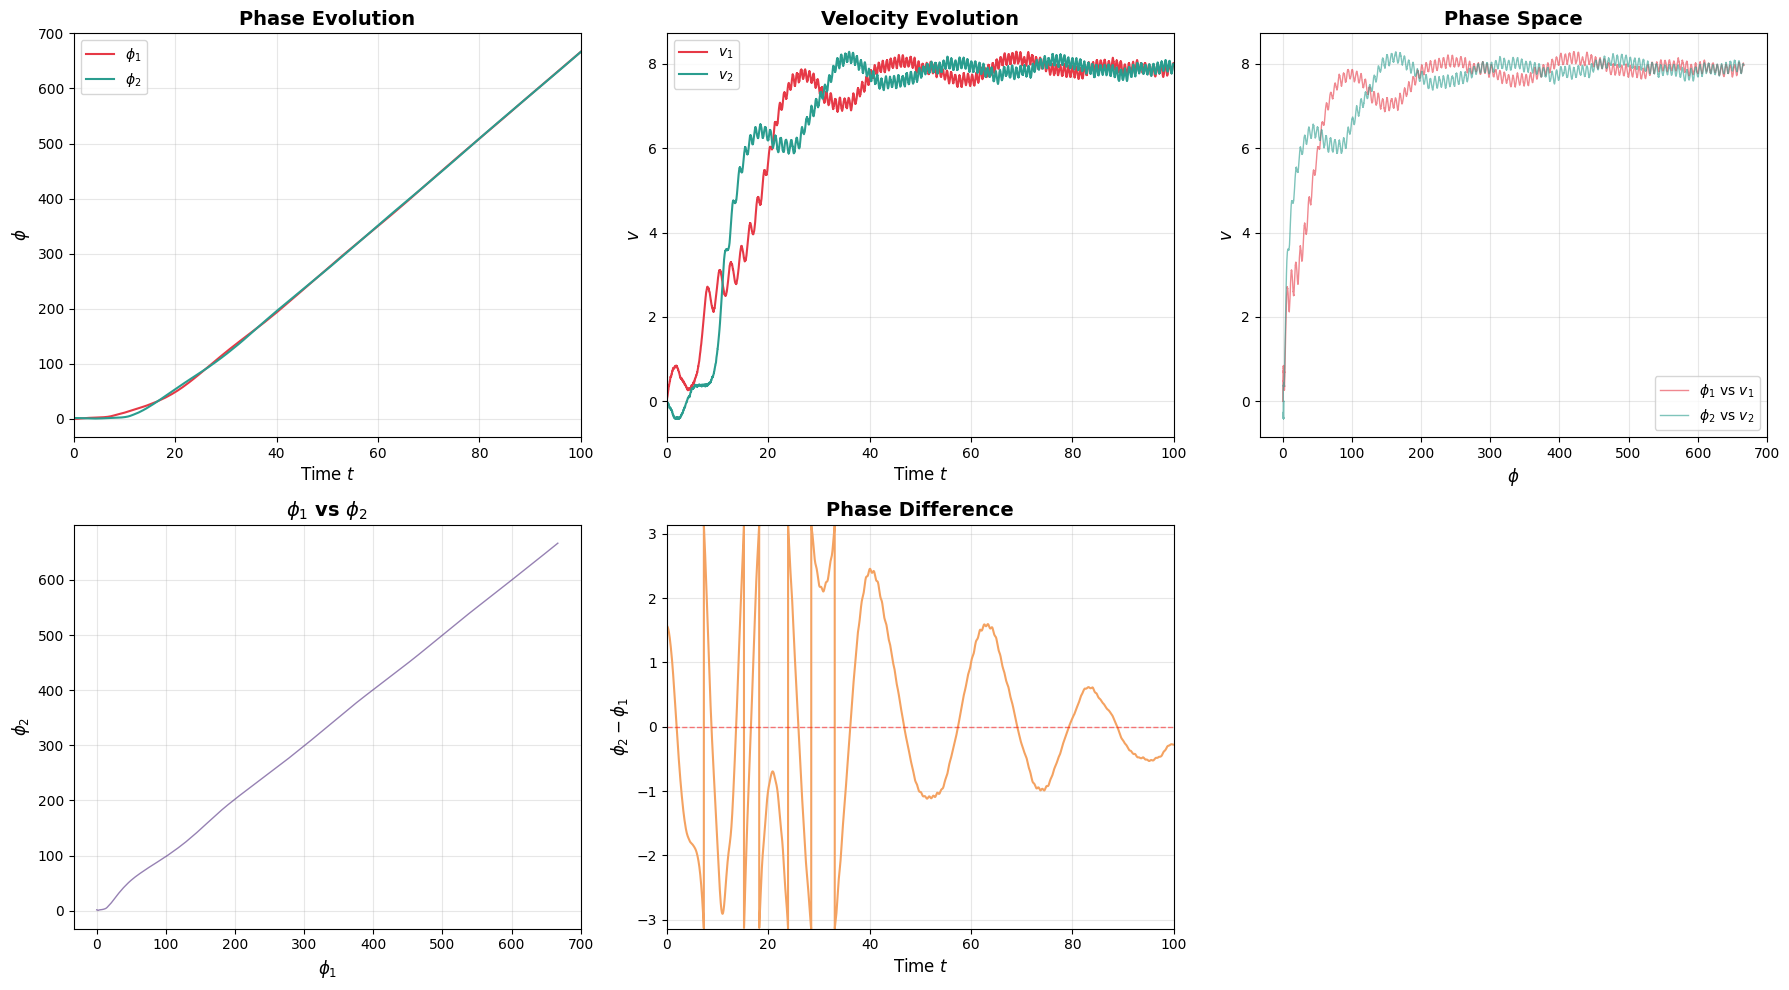

五个图绘制完成!


In [121]:

# 创建5个子图的布局 (2行3列，最后一个位置留空或放colorbar)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

# 颜色设置
color1 = '#E63946'  # 红色系
color2 = '#2A9D8F'  # 青绿色系
color_diff = '#F4A261'  # 橙色系

# 图1: phi1 和 phi2 随时间的变化
ax1 = axes[0]
ax1.plot(t, phi1, color=color1, linewidth=1.5, label=r'$\phi_1$')
ax1.plot(t, phi2, color=color2, linewidth=1.5, label=r'$\phi_2$')
ax1.set_xlabel('Time $t$', fontsize=12)
ax1.set_ylabel(r'$\phi$', fontsize=12)
ax1.set_title('Phase Evolution', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_xlim([0, 100])

# 图2: v1 和 v2 随时间的变化
ax2 = axes[1]
ax2.plot(t, v1, color=color1, linewidth=1.5, label=r'$v_1$')
ax2.plot(t, v2, color=color2, linewidth=1.5, label=r'$v_2$')
ax2.set_xlabel('Time $t$', fontsize=12)
ax2.set_ylabel(r'$v$', fontsize=12)
ax2.set_title('Velocity Evolution', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_xlim([0, 100])

# 图3: phi 和 v 的关系（相空间图）
ax3 = axes[2]
# 对phi取模2pi以便更好展示
ax3.plot(phi1, v1, color=color1, linewidth=1, alpha=0.6, label=r'$\phi_1$ vs $v_1$')
ax3.plot(phi2, v2, color=color2, linewidth=1, alpha=0.6, label=r'$\phi_2$ vs $v_2$')
ax3.set_xlabel(r'$\phi$', fontsize=12)
ax3.set_ylabel(r'$v$', fontsize=12)
ax3.set_title('Phase Space', fontsize=14, fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)

# 图4: phi1 和 phi2 之间的关系
ax4 = axes[3]
ax4.plot(phi1, phi2, color='#6A4C93', linewidth=1, alpha=0.7)
ax4.set_xlabel(r'$\phi_1$', fontsize=12)
ax4.set_ylabel(r'$\phi_2$', fontsize=12)
ax4.set_title(r'$\phi_1$ vs $\phi_2$', fontsize=14, fontweight='bold')
ax4.grid(True, alpha=0.3)
# 添加对角线参考线
# ax4.plot([-np.pi, np.pi], [-np.pi, np.pi], 'k--', alpha=0.3, linewidth=1)

# 图5: phi1 和 phi2 的相位差
ax5 = axes[4]
ax5.plot(t, phase_diff, color=color_diff, linewidth=1.5)
ax5.axhline(y=0, color='red', linestyle='--', alpha=0.5, linewidth=1)
ax5.set_xlabel('Time $t$', fontsize=12)
ax5.set_ylabel(r'$\phi_2 - \phi_1$', fontsize=12)
ax5.set_title('Phase Difference', fontsize=14, fontweight='bold')
ax5.grid(True, alpha=0.3)
ax5.set_xlim([0, 100])
ax5.set_ylim([-np.pi, np.pi])

# 隐藏第6个子图（多余的位置）
axes[5].axis('off')

# plt.suptitle('Coupled Josephson Junctions: Five Key Plots', fontsize=16, fontweight='bold')
plt.tight_layout()
# plt.savefig('/mnt/kimi/output/five_plots.png', dpi=150, bbox_inches='tight')
plt.show()

print("五个图绘制完成!")
